---
## PARTIE 1 — SETUP
---

In [1]:
# ============================================================
# CELLULE 1 — Vérification du GPU
# ============================================================
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)

import torch
print(f"GPU disponible : {torch.cuda.is_available()}")
print(f"GPU : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Aucun'}")
print(f"VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB" if torch.cuda.is_available() else "")

Fri Mar 20 08:52:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   30C    P0             50W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
# ============================================================
# CELLULE 2 — Installation des dépendances
# ============================================================

# LightOnOCR-2 nécessite transformers v5 depuis la source
!pip install -q git+https://github.com/huggingface/transformers
!pip install -q pillow pypdfium2
!pip install -q peft        # LoRA
!pip install -q accelerate  # Entraînement optimisé
!pip install -q jiwer       # Métriques CER/WER
!pip install -q datasets

print("✅ Installation terminée")
# jiwer pour les métriques CER/WER
!pip install jiwer -q


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 95.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 60.3 MB/s eta 0:00:00
✅ Installation terminée


In [3]:
# ============================================================
# CELLULE 3 — Montage Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os

DATASET_PATH = "/content/drive/MyDrive/RF/hf_dataset"
MODEL_SAVE_PATH = "/content/drive/MyDrive/RF/modele_finetuned"

# Vérification
if os.path.exists(DATASET_PATH):
    print(f"✅ Dataset trouvé : {DATASET_PATH}")
    print(f"   Contenu : {os.listdir(DATASET_PATH)}")
else:
    print(f"❌ Dataset non trouvé : {DATASET_PATH}")
    print("   Vérifie le chemin sur ton Drive")

Mounted at /content/drive
✅ Dataset trouvé : /content/drive/MyDrive/RF/hf_dataset
   Contenu : ['dataset_dict.json', 'val', 'test', 'train']


---
##  PARTIE 2 — FINE-TUNING
---

In [ ]:
# ============================================================
# CELLULE 4 — Chargement du dataset
# ============================================================
from datasets import load_from_disk

dataset = load_from_disk(DATASET_PATH)

print("📊 Dataset chargé :")
print(dataset)
print(f"\n  Train : {len(dataset['train'])} exemples")
print(f"  Val   : {len(dataset['val'])} exemples")
print(f"  Test  : {len(dataset['test'])} exemples")

# Aperçu d'un exemple
exemple = dataset["train"][0]
print(f"\n👁️  Exemple train[0] :")
print(f"  Nom   : {exemple['nom']}")
print(f"  Image : {exemple['image'].size}")
print(f"  Texte (50 premiers chars) : {exemple['text'][:50]}...")

📊 Dataset chargé :
DatasetDict({
    train: Dataset({
        features: ['image', 'text', 'nom'],
        num_rows: 210
    })
    val: Dataset({
        features: ['image', 'text', 'nom'],
        num_rows: 45
    })
    test: Dataset({
        features: ['image', 'text', 'nom'],
        num_rows: 45
    })
})

  Train : 210 exemples
  Val   : 45 exemples
  Test  : 45 exemples

👁️  Exemple train[0] :
  Nom   : cert-10
  Image : (2480, 3508)
  Texte (50 premiers chars) : RÉPUBLIQUE DÉMOCRATIQUE DU CONGO
Province de : KIN...


In [ ]:
# ============================================================
# CELLULE 5 — Chargement modèle + processor
# ============================================================
import torch
from transformers import LightOnOcrForConditionalGeneration, LightOnOcrProcessor

MODEL_ID = "lightonai/LightOnOCR-2-1B"

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype  = torch.bfloat16 if device == "cuda" else torch.float32

print(f"⚙️  Device : {device}")
print(f"⚙️  Dtype  : {dtype}")
print(f"📥 Chargement de {MODEL_ID}...")

processor = LightOnOcrProcessor.from_pretrained(MODEL_ID)

model = LightOnOcrForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype,
)

model = model.to(device)

# Paramètres totaux
total_params = sum(p.numel() for p in model.parameters())
print(f"\n✅ Modèle chargé")
print(f"   Paramètres totaux : {total_params / 1e9:.2f}B")

⚙️  Device : cuda
⚙️  Dtype  : torch.bfloat16
📥 Chargement de lightonai/LightOnOCR-2-1B...


processor_config.json: 0.00B [00:00, ?B/s]

chat_template.jinja:   0%|          | 0.00/720 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

You are using a model of type `mistral3` to instantiate a model of type `lighton_ocr`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Loading weights:   0%|          | 0/532 [00:00<?, ?it/s]


✅ Modèle chargé
   Paramètres totaux : 1.01B


In [ ]:
# ============================================================
# CELLULE 6 — Configuration LoRA (PEFT)
# ============================================================
from peft import LoraConfig, get_peft_model, TaskType


lora_config = LoraConfig(
    r=32,                     # Rang LoRA — plus grand = plus de params entraînés
    lora_alpha=64,            # Scaling factor
    target_modules=[          # Couches à adapter
        "q_proj",
        "v_proj",
        "k_proj",
        "o_proj",
    ],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.SEQ_2_SEQ_LM,
)

model = get_peft_model(model, lora_config)

# Afficher les paramètres entraînables
model.print_trainable_parameters()

# Résumé
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"\n✅ LoRA configuré")
print(f"   Paramètres entraînables : {trainable / 1e6:.1f}M / {total / 1e9:.2f}B ({100*trainable/total:.2f}%)")

trainable params: 15,466,496 || all params: 1,021,114,368 || trainable%: 1.5147

✅ LoRA configuré
   Paramètres entraînables : 15.5M / 1.02B (1.51%)


In [ ]:
# ============================================================
# CELLULE 7 — Preprocessing corrigé (format causal LM)
# ============================================================
from PIL import Image
Image.MAX_IMAGE_PIXELS = None

def preprocess(batch):
    images = [
        img.convert("RGB").resize((1240, 1754), Image.LANCZOS)
        for img in batch["image"]
    ]
    textes = batch["text"]

    input_ids_list      = []
    attention_mask_list = []
    labels_list         = []

    for img, texte in zip(images, textes):

        # 1. Encoder le prompt (image seule)
        conversation = [{
            "role": "user",
             "content": [
                 {"type": "image", "image": img},
                 {"type": "text",  "text": "Transcris exactement le texte de ce document sans markdown."}
                 ]
            }]


        prompt_inputs = processor.apply_chat_template(
            conversation,
            add_generation_prompt=True,
            tokenize=True,
            return_dict=True,
            return_tensors="pt",
        )
        prompt_ids  = prompt_inputs["input_ids"].squeeze()   # [L_prompt]
        prompt_len  = prompt_ids.shape[0]

        # 2. Encoder la réponse (texte attendu)
        response_ids = processor.tokenizer(
            texte,
            return_tensors="pt",
            padding=False,
            truncation=True,
            max_length=512,
            add_special_tokens=False,
        )["input_ids"].squeeze()                             # [L_response]

        # Ajouter EOS token
        eos = torch.tensor([processor.tokenizer.eos_token_id])
        response_ids = torch.cat([response_ids, eos], dim=0)

        # 3. Concaténer prompt + réponse
        full_ids = torch.cat([prompt_ids, response_ids], dim=0)  # [L_total]

        # 4. Labels : -100 sur le prompt, réponse sur le reste
        labels = torch.full_like(full_ids, -100)
        labels[prompt_len:] = response_ids

        # 5. Attention mask
        attention_mask = torch.ones_like(full_ids)

        input_ids_list.append(full_ids)
        attention_mask_list.append(attention_mask)
        labels_list.append(labels)

    return {
        "input_ids":      [t.tolist() for t in input_ids_list],
        "attention_mask": [t.tolist() for t in attention_mask_list],
        "labels":         [t.tolist() for t in labels_list],
    }


print("🔧 Preprocessing train...")
train_dataset = dataset["train"].map(
    preprocess,
    batched=True,
    batch_size=2,
    remove_columns=["image", "text", "nom"],
    desc="Train"
)

print("🔧 Preprocessing val...")
val_dataset = dataset["val"].map(
    preprocess,
    batched=True,
    batch_size=2,
    remove_columns=["image", "text", "nom"],
    desc="Val"
)

print(f"\n✅ Preprocessing terminé")
print(f"   Train : {len(train_dataset)} exemples")
print(f"   Val   : {len(val_dataset)} exemples")

# Vérification longueurs
ex = train_dataset[0]
print(f"\n🔍 Vérification train[0] :")
print(f"   input_ids len      : {len(ex['input_ids'])}")
print(f"   attention_mask len : {len(ex['attention_mask'])}")
print(f"   labels len         : {len(ex['labels'])}")
print(f"   → Longueurs égales : {len(ex['input_ids']) == len(ex['labels'])}")

🔧 Preprocessing train...


Train:   0%|          | 0/210 [00:00<?, ? examples/s]

🔧 Preprocessing val...


Val:   0%|          | 0/45 [00:00<?, ? examples/s]


✅ Preprocessing terminé
   Train : 210 exemples
   Val   : 45 exemples

🔍 Vérification train[0] :
   input_ids len      : 2683
   attention_mask len : 2683
   labels len         : 2683
   → Longueurs égales : True


In [ ]:
# ============================================================
# CELLULE 8 — Data Collator (padding dynamique)
# ============================================================
import torch
from torch.nn.utils.rnn import pad_sequence

class OCRDataCollator:
    def __init__(self, processor):
        self.pad_token_id = processor.tokenizer.pad_token_id

    def __call__(self, batch):
        input_ids      = [torch.tensor(b["input_ids"])      for b in batch]
        attention_mask = [torch.tensor(b["attention_mask"]) for b in batch]
        labels         = [torch.tensor(b["labels"])         for b in batch]

        # Padding
        input_ids_padded = pad_sequence(
            input_ids, batch_first=True,
            padding_value=self.pad_token_id
        )
        attention_mask_padded = pad_sequence(
            attention_mask, batch_first=True, padding_value=0
        )
        labels_padded = pad_sequence(
            labels, batch_first=True, padding_value=-100  # -100 = ignoré dans la loss
        )

        return {
            "input_ids":      input_ids_padded,
            "attention_mask": attention_mask_padded,
            "labels":         labels_padded,
        }


data_collator = OCRDataCollator(processor)
print("✅ Data Collator prêt")

✅ Data Collator prêt


In [ ]:
# ============================================================
# CELLULE 10 — Métriques CER / WER
# ============================================================
from jiwer import cer, wer
import numpy as np

def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    # Décoder les prédictions
    pred_ids = np.argmax(predictions[0], axis=-1) if isinstance(predictions, tuple) else predictions
    pred_texts = processor.tokenizer.batch_decode(pred_ids, skip_special_tokens=True)

    # Décoder les labels (remplacer -100 par pad_token_id)
    labels = np.where(labels != -100, labels, processor.tokenizer.pad_token_id)
    label_texts = processor.tokenizer.batch_decode(labels, skip_special_tokens=True)

    # Calculer CER et WER
    cer_score = cer(label_texts, pred_texts)
    wer_score = wer(label_texts, pred_texts)

    # Afficher quelques exemples
    print(f"\n📊 Exemple prédiction :")
    print(f"   Attendu  : {label_texts[0][:80]}...")
    print(f"   Prédit   : {pred_texts[0][:80]}...")

    return {
        "cer": round(cer_score, 4),
        "wer": round(wer_score, 4),
    }

print("✅ Métriques CER/WER prêtes")

✅ Métriques CER/WER prêtes


In [ ]:
# ============================================================
# CELLULE 9 — Configuration entraînement
# ============================================================

from transformers import TrainingArguments
training_args = TrainingArguments(
    output_dir="./checkpoints",
    num_train_epochs=15,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    warmup_steps=100,
    weight_decay=0.01,
    fp16=True,
    gradient_checkpointing=True,
    optim="adafactor",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    logging_steps=5,
    report_to="none",
    seed=42,
)

print("✅ Configuration entraînement prête")
print(f"   Epochs         : {training_args.num_train_epochs}")
print(f"   Batch size     : {training_args.per_device_train_batch_size}")
print(f"   Grad accum     : {training_args.gradient_accumulation_steps}")
print(f"   Learning rate  : {training_args.learning_rate}")
print(f"   FP16           : {training_args.fp16}")

✅ Configuration entraînement prête
   Epochs         : 15
   Batch size     : 1
   Grad accum     : 8
   Learning rate  : 0.0002
   FP16           : True


In [ ]:
# ============================================================
# CELLULE 11 — Fine-tuning
# ============================================================
from transformers import Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
)

print("🚀 Lancement du fine-tuning...")
print(f"   {len(train_dataset)} exemples d'entraînement")
print(f"   {len(val_dataset)} exemples de validation")
print("="*50)

trainer.train()

print("\n✅ Fine-tuning terminé !")

🚀 Lancement du fine-tuning...
   210 exemples d'entraînement
   45 exemples de validation


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Epoch,Training Loss,Validation Loss
1,2.560118,2.281910
2,1.035996,0.796617
3,0.542643,0.518994
4,0.397279,0.437679
5,0.314410,0.344218
6,0.292296,0.311920
7,0.261247,0.297197
8,0.249833,0.287472
9,0.244605,0.280995
10,0.241674,0.267913



✅ Fine-tuning terminé !


In [ ]:
# ============================================================
# CELLULE NETTOYAGE
# ============================================================
import torch, gc

# Désactiver gradient checkpointing pour l'inférence
model.gradient_checkpointing_disable()

# Passer en mode évaluation
model.eval()

# Libérer toute la mémoire
for param in model.parameters():
    param.grad = None

gc.collect()
torch.cuda.empty_cache()

# Vérifier la mémoire disponible
libre = (torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1e9
print(f"✅ Mémoire libérée")
print(f"   VRAM libre : {libre:.1f} GB")

✅ Mémoire libérée
   VRAM libre : 40.3 GB


In [ ]:
# Cellule 13
import os
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

model.save_pretrained(
    MODEL_SAVE_PATH,
    save_embedding_layers=True,
)
processor.save_pretrained(MODEL_SAVE_PATH)

print(f"✅ Modèle sauvegardé : {MODEL_SAVE_PATH}")
print(f"   Contenu : {os.listdir(MODEL_SAVE_PATH)}")

# Vérifier la taille
for f in os.listdir(MODEL_SAVE_PATH):
    taille = os.path.getsize(os.path.join(MODEL_SAVE_PATH, f))
    print(f"   {f} → {taille/1024/1024:.1f} MB")


✅ Modèle sauvegardé : /content/drive/MyDrive/RF/modele_finetuned
   Contenu : ['tokenizer.json', 'README.md', 'chat_template.jinja', 'adapter_config.json', 'processor_config.json', 'tokenizer_config.json', 'adapter_model.safetensors']
   tokenizer.json → 10.9 MB
   README.md → 0.0 MB
   chat_template.jinja → 0.0 MB
   adapter_config.json → 0.0 MB
   processor_config.json → 0.0 MB
   tokenizer_config.json → 0.0 MB
   adapter_model.safetensors → 652.6 MB


In [ ]:
import os
chemin = "/content/drive/MyDrive/RF/modele_finetuned"
fichiers = os.listdir(chemin)
print(f"Fichiers sauvegardés :")
for f in fichiers:
    taille = os.path.getsize(os.path.join(chemin, f))
    print(f"  {f} → {taille/1024/1024:.1f} MB")

Fichiers sauvegardés :
  tokenizer.json → 10.9 MB
  README.md → 0.0 MB
  chat_template.jinja → 0.0 MB
  adapter_config.json → 0.0 MB
  processor_config.json → 0.0 MB
  tokenizer_config.json → 0.0 MB
  adapter_model.safetensors → 59.1 MB


In [ ]:
# Charger LoRA sauvegardé (sans réentraîner)
from peft import PeftModel

LORA_PATH = "/content/drive/MyDrive/RF/modele_finetuned"
model = PeftModel.from_pretrained(base_model, LORA_PATH)
model.eval()
print("✅ LoRA chargé !")

# Fusionner et sauvegarder
merged = model.merge_and_unload()

MERGED = "/content/drive/MyDrive/RF/modele_merged_complet"
merged.save_pretrained(MERGED)
processor.save_pretrained(MERGED)
print("✅ Merge terminé !")

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


✅ LoRA chargé !


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Merge terminé !


In [15]:
# ============================================================
# CELLULE 14 — Test du modèle sauvegardé
# ============================================================
from peft import PeftModel
from transformers import LightOnOcrForConditionalGeneration, LightOnOcrProcessor
import torch

# ── Variables nécessaires ──
MODEL_ID       = "lightonai/LightOnOCR-2-1B"
MODEL_SAVE_PATH = "/content/drive/MyDrive/RF/modele_finetuned"
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype  = torch.bfloat16 if device == "cuda" else torch.float32

# Recharger depuis Drive
print("📥 Rechargement du modèle sauvegardé...")

base_model = LightOnOcrForConditionalGeneration.from_pretrained(
    MODEL_ID, torch_dtype=dtype
).to(device)

model_reloaded = PeftModel.from_pretrained(base_model, MODEL_SAVE_PATH)
model_reloaded.eval()

# Test sur le premier certificat
exemple = dataset["test"][0]
image = exemple["image"].convert("RGB").resize((1240, 1754))

conversation = [{"role": "user", "content": [
    {"type": "image", "image": image},
    {"type": "text", "text": "Transcris exactement le texte de ce document sans markdown."}
]}]

inputs = processor.apply_chat_template(
    conversation, add_generation_prompt=True,
    tokenize=True, return_dict=True, return_tensors="pt"
)
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    output_ids = model_reloaded.generate(**inputs, max_new_tokens=1024, do_sample=False)

generated = output_ids[0, inputs["input_ids"].shape[1]:]
texte = processor.decode(generated, skip_special_tokens=True)

print("\n📄 Texte prédit :")
print(texte[:500])

📥 Rechargement du modèle sauvegardé...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

You are using a model of type `mistral3` to instantiate a model of type `lighton_ocr`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


model.safetensors:   0%|          | 0.00/2.01G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/532 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/219 [00:00<?, ?B/s]


📄 Texte prédit :
# REPUBLIQUE DEMOCRATIQUE DU CONGO

Province de KINSHASA  
Ville de KINSHASA  
District de TSHANGU  
Territoire / Secteur ou Cite de KINSHASA  
Chefferie/secteur ou Cite de KINSHASA  
Bureau Principal de l'Etat civil de KINSHASA  
Bureau secondaire de l'Etat civil de KINSHASA  
Acte n° 0081026 - Jumel 11.10.26 - Follo n° 0008  

Volet

---

## ACTE DE NAISSANCE

L'an deux mille VINGT-SIX, le VINGT-QUATIEME jour du mois de JANVIER à 13 heures 00.  
Par devant nous * KASONGO MWILA ROBERT  
Officie


In [ ]:
import os

taille = 0
for f in os.listdir("/content/drive/MyDrive/RF/modele_merged_complet"):
    chemin = f"/content/drive/MyDrive/RF/modele_merged_complet/{f}"
    taille += os.path.getsize(chemin)

print(f"Taille totale : {taille / 1e9:.2f} GB")


Taille totale : 2.02 GB


---
## PARTIE 3 — ÉVALUATION
---

In [4]:
# ============ CELLULE 1 : Imports ============
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
from datasets import load_from_disk
from transformers import AutoProcessor, AutoModelForImageTextToText

print("✅ Imports OK")

✅ Imports OK


In [5]:
# ============ CELLULE 2 : Chargement modèle ============
MODEL_PATH = "/content/drive/MyDrive/RF/modele_merged_complet"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}")

processor = AutoProcessor.from_pretrained(
    MODEL_PATH,
    trust_remote_code=True
)

model = AutoModelForImageTextToText.from_pretrained(
    MODEL_PATH,
    torch_dtype=torch.float32,
    device_map=device,
    trust_remote_code=True
)
model.eval()
print("✅ Modèle chargé !")

Device : cuda


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/532 [00:00<?, ?it/s]

✅ Modèle chargé !


In [6]:
# ============ CELLULE 3 : Charger dataset + TEST_SET ============
DATASET_PATH = "/content/drive/MyDrive/RF/hf_dataset"
dataset = load_from_disk(DATASET_PATH)
test_set = dataset["test"]

print(f"✅ {len(test_set)} certificats de test chargés")

TEST_SET = [
    (test_set[i]["image"], test_set[i]["text"])
    for i in range(len(test_set))
]

print(f"✅ TEST_SET prêt avec {len(TEST_SET)} certificats")
print(f"Exemple : '{test_set[0]['text'][:80]}...'")

✅ 45 certificats de test chargés
✅ TEST_SET prêt avec 45 certificats
Exemple : 'RÉPUBLIQUE DÉMOCRATIQUE DU CONGO
Province de : KINSHASA
Ville de : KINSHASA
Dist...'


In [7]:
# ============ CELLULE 4 : Métriques ============
def cer(reference, hypothese):
    if not reference: return 0.0
    ref, hyp = list(reference), list(hypothese)
    d = np.zeros((len(ref)+1, len(hyp)+1))
    for i in range(len(ref)+1): d[i][0] = i
    for j in range(len(hyp)+1): d[0][j] = j
    for i in range(1, len(ref)+1):
        for j in range(1, len(hyp)+1):
            d[i][j] = d[i-1][j-1] if ref[i-1]==hyp[j-1] else 1+min(d[i-1][j],d[i][j-1],d[i-1][j-1])
    return d[len(ref)][len(hyp)] / len(ref)

def wer(reference, hypothese):
    if not reference: return 0.0
    ref, hyp = reference.split(), hypothese.split()
    d = np.zeros((len(ref)+1, len(hyp)+1))
    for i in range(len(ref)+1): d[i][0] = i
    for j in range(len(hyp)+1): d[0][j] = j
    for i in range(1, len(ref)+1):
        for j in range(1, len(hyp)+1):
            d[i][j] = d[i-1][j-1] if ref[i-1]==hyp[j-1] else 1+min(d[i-1][j],d[i][j-1],d[i-1][j-1])
    return d[len(ref)][len(hyp)] / len(ref)

def calculer_tp_fp_fn(reference, hypothese):
    ref = list(reference)
    hyp = list(hypothese)
    d = np.zeros((len(ref)+1, len(hyp)+1), dtype=int)
    for i in range(len(ref)+1): d[i][0] = i
    for j in range(len(hyp)+1): d[0][j] = j
    for i in range(1, len(ref)+1):
        for j in range(1, len(hyp)+1):
            if ref[i-1] == hyp[j-1]:
                d[i][j] = d[i-1][j-1]
            else:
                d[i][j] = 1 + min(d[i-1][j], d[i][j-1], d[i-1][j-1])

    i, j = len(ref), len(hyp)
    substitutions = insertions = suppressions = 0
    while i > 0 or j > 0:
        if i > 0 and j > 0 and ref[i-1] == hyp[j-1]:
            i -= 1; j -= 1
        elif i > 0 and j > 0 and d[i][j] == d[i-1][j-1] + 1:
            substitutions += 1; i -= 1; j -= 1
        elif j > 0 and d[i][j] == d[i][j-1] + 1:
            insertions += 1; j -= 1
        else:
            suppressions += 1; i -= 1

    TP = len(ref) - substitutions - suppressions
    FP = substitutions + insertions
    FN = substitutions + suppressions
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1        = 2*precision*recall / (precision+recall) if (precision+recall) > 0 else 0

    return {
        "TP": TP, "FP": FP, "FN": FN,
        "precision": precision * 100,
        "recall": recall * 100,
        "f1": f1 * 100,
        "substitutions": substitutions,
        "insertions": insertions,
        "suppressions": suppressions
    }

print("✅ Fonctions métriques OK")

✅ Fonctions métriques OK


In [8]:
def predire(image):
    image = image.convert("RGB").resize((1240, 1754))

    conversation = [{"role": "user", "content": [
        {"type": "image", "image": image},
        {"type": "text", "text": "Transcris exactement le texte de ce document sans markdown."}
    ]}]

    inputs = processor.apply_chat_template(
        conversation, add_generation_prompt=True,
        tokenize=True, return_dict=True, return_tensors="pt"
    )

    # ← CORRECTION : convertir pixel_values en float16
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=1024,
            do_sample=False
        )

    generated = output_ids[0, inputs["input_ids"].shape[1]:]
    return processor.decode(generated, skip_special_tokens=True)

print("✅ Fonction predire() corrigée !")

✅ Fonction predire() corrigée !


In [9]:
# ============ CELLULE 6 : Inférence sur les 45 certificats ============
resultats_complets = []
predictions = []
ground_truths = []
cer_scores = []
wer_scores = []

for i, (image, gt) in enumerate(TEST_SET):
    print(f"⏳ Certificat {i+1}/{len(TEST_SET)}...")

    pred = predire(image)

    print(f"   GT   : '{gt[:80]}'")
    print(f"   PRED : '{pred[:80]}'")
    print()
    metriques = calculer_tp_fp_fn(gt, pred)
    metriques["certificat"] = f"Cert {i+1}"
    metriques["cer"] = cer(gt, pred) * 100
    metriques["wer"] = wer(gt, pred) * 100

    predictions.append(pred)
    ground_truths.append(gt)
    cer_scores.append(metriques["cer"])
    wer_scores.append(metriques["wer"])
    resultats_complets.append(metriques)

    print(f"   ✅ CER: {metriques['cer']:.1f}% | WER: {metriques['wer']:.1f}% | F1: {metriques['f1']:.1f}%")

print(f"\n📊 CER moyen : {np.mean(cer_scores):.2f}%")
print(f"📊 WER moyen : {np.mean(wer_scores):.2f}%")
print(f"📊 F1 moyen  : {np.mean([r['f1'] for r in resultats_complets]):.2f}%")

⏳ Certificat 1/45...


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


   GT   : 'RÉPUBLIQUE DÉMOCRATIQUE DU CONGO
Province de : KINSHASA
Ville de : KINSHASA
Dist'
   PRED : '# REPUBLIQUE DEMOCRATIQUE DU CONGO

Province de KINSHASA  
Ville de KINSHASA  
D'

   ✅ CER: 14.2% | WER: 25.9% | F1: 89.4%
⏳ Certificat 2/45...
   GT   : 'RÉPUBLIQUE DÉMOCRATIQUE DU CONGO
Province de : KINSHASA
Ville de : KINSHASA
Dist'
   PRED : '# REPUBLIQUE DEMOCRATIQUE DU CONGO

Province de... KINSHASA  
Ville de... KINSHA'

   ✅ CER: 15.2% | WER: 35.6% | F1: 89.4%
⏳ Certificat 3/45...
   GT   : 'RÉPUBLIQUE DÉMOCRATIQUE DU CONGO
Province de : KINSHASA
Ville de : KINSHASA
Dist'
   PRED : '# REPUBLIQUE DEMOCRATIQUE DU CONGO

Province de: Kinshasa  
Ville de: Kinshasa  '

   ✅ CER: 28.3% | WER: 42.3% | F1: 78.2%
⏳ Certificat 4/45...
   GT   : 'RÉPUBLIQUE DÉMOCRATIQUE DU CONGO
Province de : KINSHASA
Ville de : KINSHASA
Dist'
   PRED : '# REPUBLIQUE DEMOCRATIQUE DU CONGO

Province de... KINSHASA  
Ville de... KINSHA'

   ✅ CER: 14.7% | WER: 28.0% | F1: 88.2%
⏳ Certificat 5/45...
   G

In [11]:
# ============ CELLULE 8 : Tableau récapitulatif ============

# ── Extraction des variables depuis resultats_complets ──
certs   = [r["certificat"]    for r in resultats_complets]
TPs     = [r["TP"]            for r in resultats_complets]
FPs     = [r["FP"]            for r in resultats_complets]
FNs     = [r["FN"]            for r in resultats_complets]
precs   = [r["precision"]     for r in resultats_complets]
recalls = [r["recall"]        for r in resultats_complets]
f1s     = [r["f1"]            for r in resultats_complets]

# ── Tableau ──
print("\n" + "="*75)
print(f"{'RAPPORT D ÉVALUATION — LightOnOCR Fine-tuné':^75}")
print("="*75)
print(f"{'Certificat':<12} {'TP':>6} {'FP':>6} {'FN':>6} "
      f"{'Précision':>10} {'Recall':>8} {'F1':>8} {'CER':>8} {'WER':>8}")
print("-"*75)
for r in resultats_complets:
    print(f"{r['certificat']:<12} {r['TP']:>6} {r['FP']:>6} {r['FN']:>6} "
          f"{r['precision']:>9.1f}% {r['recall']:>7.1f}% "
          f"{r['f1']:>7.1f}% {r['cer']:>7.1f}% {r['wer']:>7.1f}%")
print("-"*75)
print(f"{'MOYENNE':<12} "
      f"{np.mean(TPs):>6.0f} {np.mean(FPs):>6.0f} {np.mean(FNs):>6.0f} "
      f"{np.mean(precs):>9.1f}% {np.mean(recalls):>7.1f}% "
      f"{np.mean(f1s):>7.1f}% {np.mean(cer_scores):>7.1f}% "
      f"{np.mean(wer_scores):>7.1f}%")
print("="*75)


                RAPPORT D ÉVALUATION — LightOnOCR Fine-tuné                
Certificat       TP     FP     FN  Précision   Recall       F1      CER      WER
---------------------------------------------------------------------------
Cert 1         1346    184    136      88.0%    90.8%    89.4%    14.2%    25.9%
Cert 2         1374    215    111      86.5%    92.5%    89.4%    15.2%    35.6%
Cert 3         1202    389    280      75.5%    81.1%    78.2%    28.3%    42.3%
Cert 4         1296    178    168      87.9%    88.5%    88.2%    14.7%    28.0%
Cert 5         1268    358    245      78.0%    83.8%    80.8%    25.4%    38.9%
Cert 6         1161    292    327      79.9%    78.0%    79.0%    26.5%    36.0%
Cert 7         1220    122     11      90.9%    99.1%    94.8%    10.6%     5.4%
Cert 8         1210    124     10      90.7%    99.2%    94.8%    10.7%     6.4%
Cert 9         1226    120      7      91.1%    99.4%    95.1%    10.3%     3.9%
Cert 10        1196    122      8    

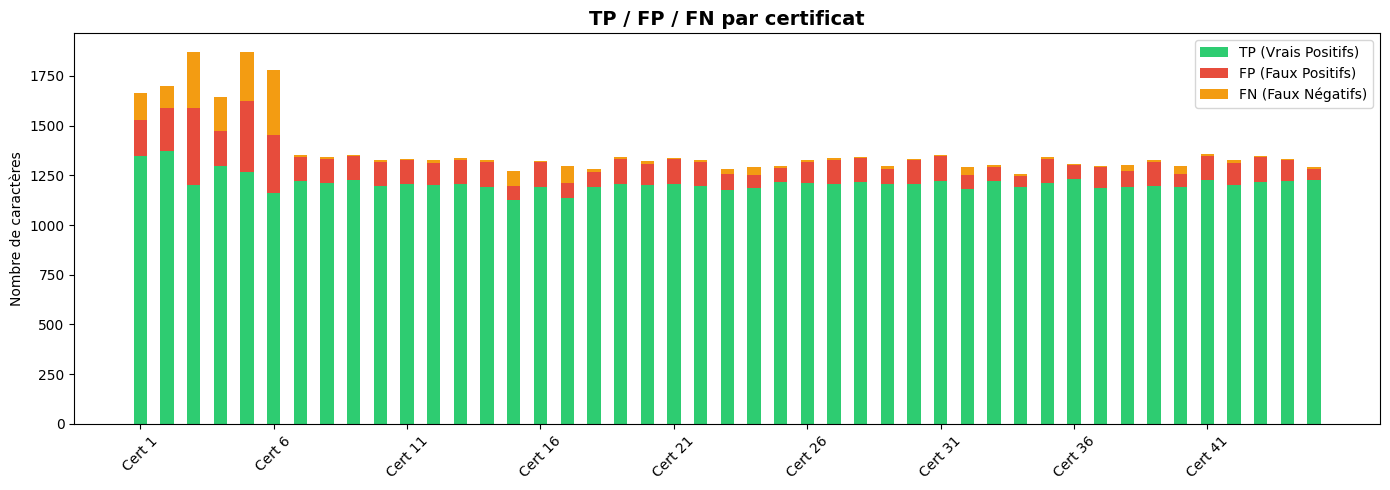

✅ Graphique 1 sauvegardé


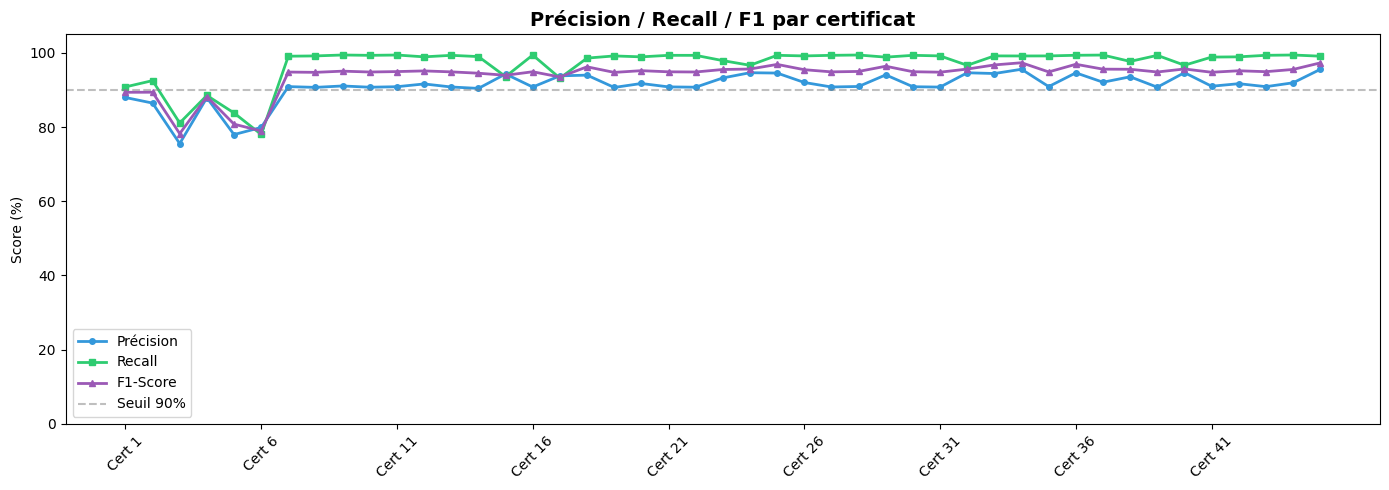

✅ Graphique 2 sauvegardé


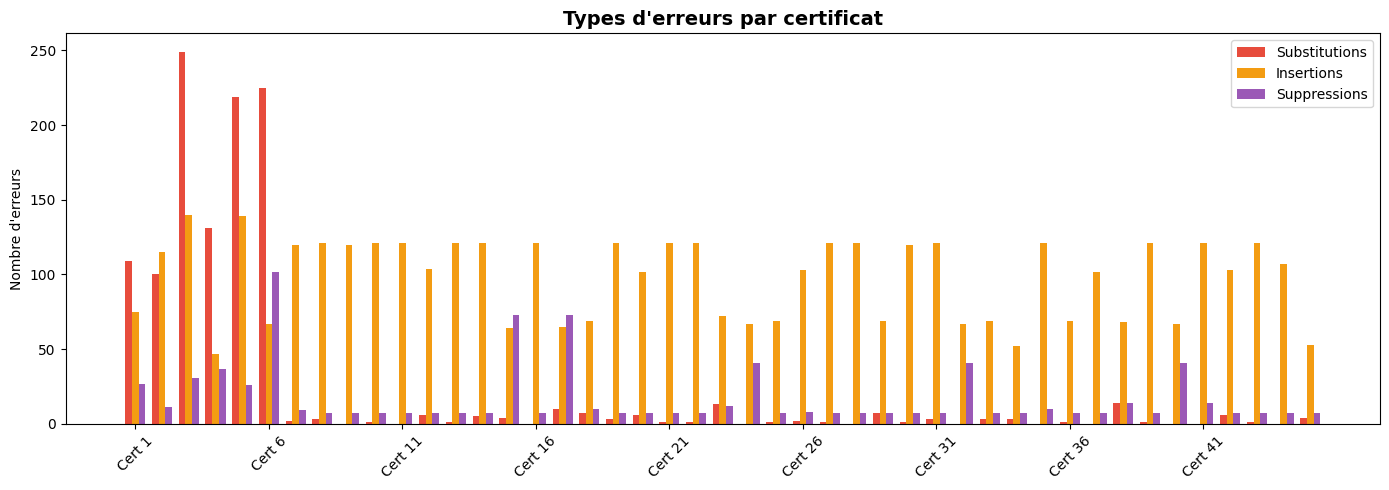

✅ Graphique 3 sauvegardé
Total substitutions dans la matrice : 1936


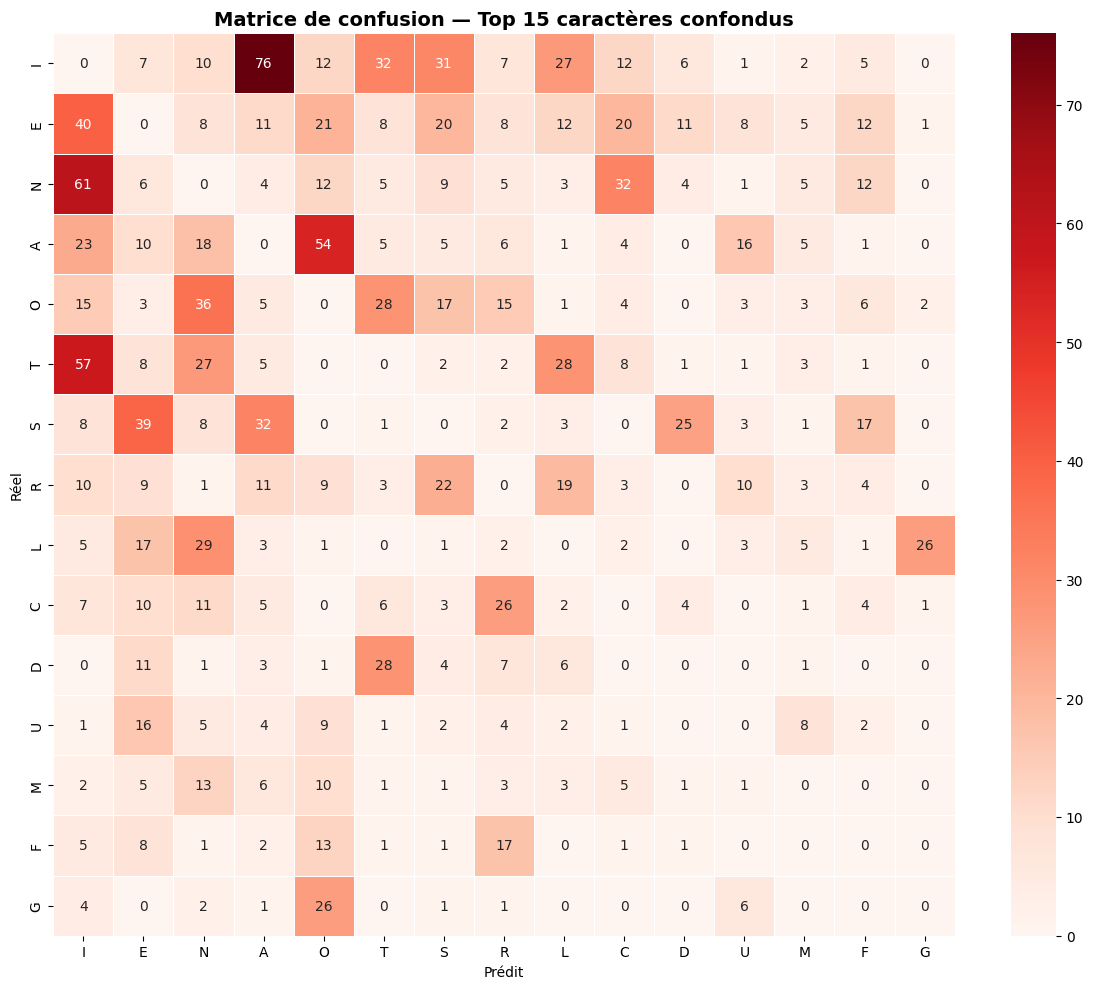

✅ Graphique 4 sauvegardé


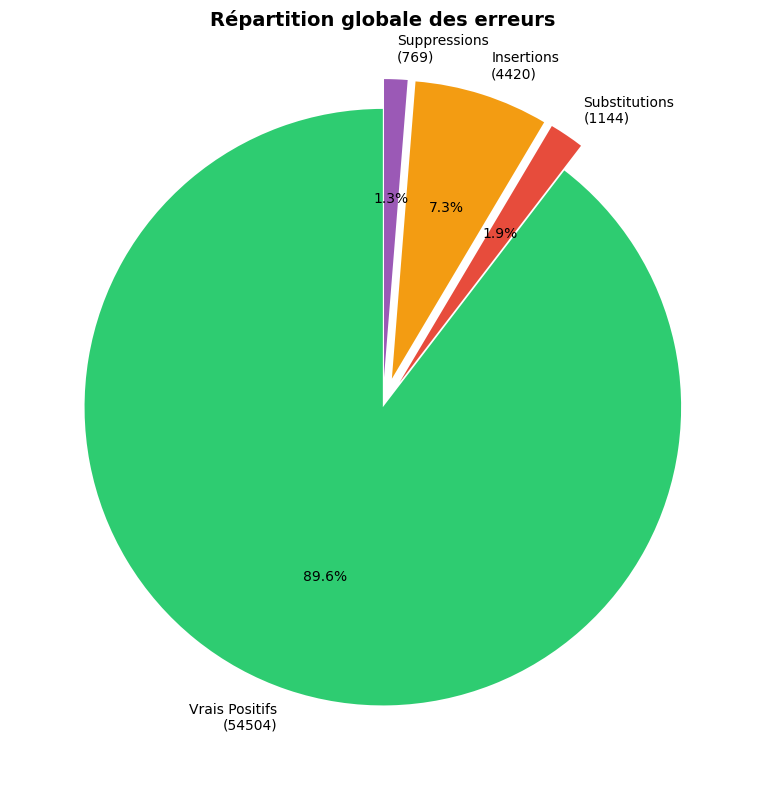

✅ Graphique 5 sauvegardé


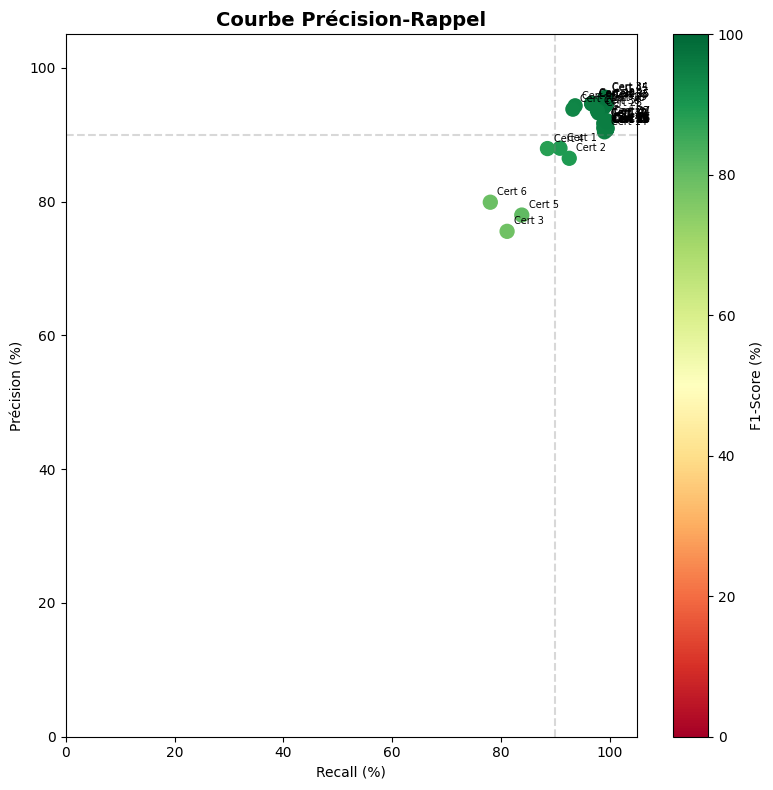

✅ Graphique 6 sauvegardé


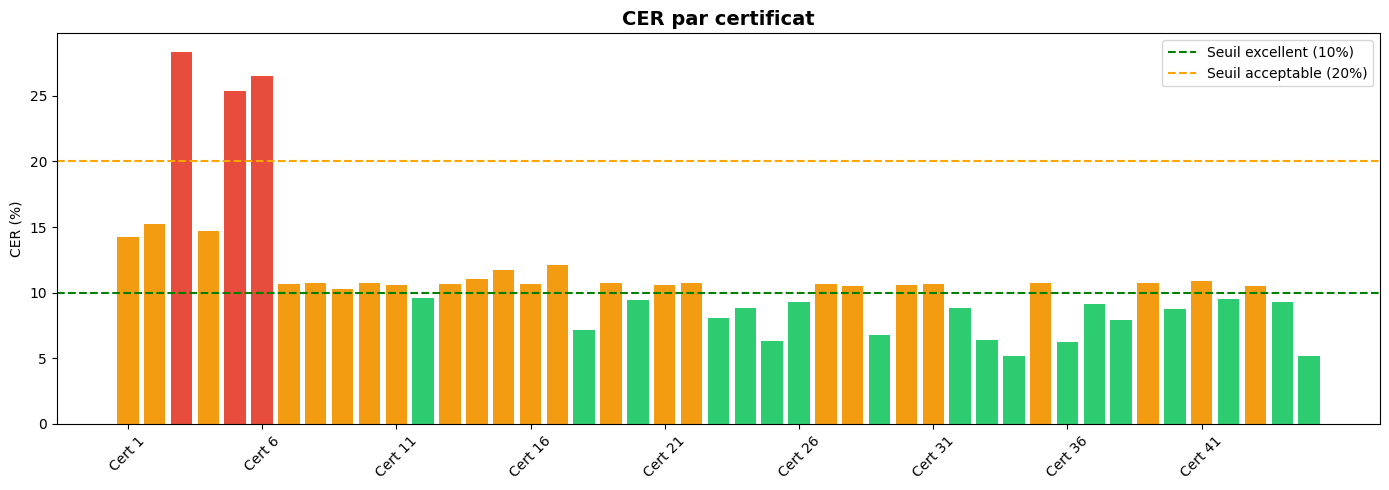

✅ Graphique 7 sauvegardé

✅ Tous les graphiques sauvegardés dans /content/drive/MyDrive/RF/graphiques/


In [12]:
# ============ CELLULE : Graphiques séparés ============
import os
from difflib import SequenceMatcher

SAVE_DIR = "/content/drive/MyDrive/RF/graphiques/"
os.makedirs(SAVE_DIR, exist_ok=True)

# Variables issues de resultats_complets (entiers, cohérents)
subs  = [r["substitutions"] for r in resultats_complets]
ins   = [r["insertions"]    for r in resultats_complets]
supps = [r["suppressions"]  for r in resultats_complets]

# ── Graphique 1 : TP/FP/FN ──
fig1, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(certs))
w = 0.5
ax.bar(x, TPs, w, label="TP (Vrais Positifs)",  color="#2ECC71")
ax.bar(x, FPs, w, bottom=TPs, label="FP (Faux Positifs)", color="#E74C3C")
ax.bar(x, FNs, w, bottom=[t+f for t,f in zip(TPs,FPs)],
       label="FN (Faux Négatifs)", color="#F39C12")
ax.set_xticks(x[::5]); ax.set_xticklabels(certs[::5], rotation=45)
ax.set_title("TP / FP / FN par certificat", fontsize=14, fontweight="bold")
ax.set_ylabel("Nombre de caractères")
ax.legend()
plt.tight_layout()
plt.savefig(SAVE_DIR + "1_tp_fp_fn.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("✅ Graphique 1 sauvegardé")

# ── Graphique 2 : Précision/Recall/F1 ──
fig2, ax = plt.subplots(figsize=(14, 5))
ax.plot(certs, precs,   "o-", color="#3498DB", linewidth=2, label="Précision",  markersize=4)
ax.plot(certs, recalls, "s-", color="#2ECC71", linewidth=2, label="Recall",     markersize=4)
ax.plot(certs, f1s,     "^-", color="#9B59B6", linewidth=2, label="F1-Score",   markersize=4)
ax.axhline(y=90, color="gray", linestyle="--", alpha=0.5, label="Seuil 90%")
ax.set_ylim(0, 105)
ax.set_xticks(range(0, len(certs), 5))
ax.set_xticklabels(certs[::5], rotation=45)
ax.set_ylabel("Score (%)")
ax.set_title("Précision / Recall / F1 par certificat", fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(SAVE_DIR + "2_precision_recall_f1.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("✅ Graphique 2 sauvegardé")

# ── Graphique 3 : Types d'erreurs ──
fig3, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(certs))
w = 0.25
ax.bar(x - w, subs,  w, label="Substitutions", color="#E74C3C")
ax.bar(x,     ins,   w, label="Insertions",     color="#F39C12")
ax.bar(x + w, supps, w, label="Suppressions",   color="#9B59B6")
ax.set_xticks(x[::5]); ax.set_xticklabels(certs[::5], rotation=45)
ax.set_title("Types d'erreurs par certificat", fontsize=14, fontweight="bold")
ax.set_ylabel("Nombre d'erreurs")
ax.legend()
plt.tight_layout()
plt.savefig(SAVE_DIR + "3_types_erreurs.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("✅ Graphique 3 sauvegardé")

# ── Graphique 4 : Matrice de confusion (SequenceMatcher) ──
fig4, ax = plt.subplots(figsize=(12, 10))
CHARS = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789")
matrice = np.zeros((len(CHARS), len(CHARS)))
for gt_text, pred_text in zip(ground_truths, predictions):
    matcher = SequenceMatcher(None, gt_text.upper(), pred_text.upper())
    for op, i1, i2, j1, j2 in matcher.get_opcodes():
        if op == "replace":
            for g, p in zip(gt_text.upper()[i1:i2], pred_text.upper()[j1:j2]):
                if g in CHARS and p in CHARS and g != p:
                    matrice[CHARS.index(g)][CHARS.index(p)] += 1
freq = matrice.sum(axis=1)
top_idx = np.argsort(freq)[-15:][::-1]
mat_reduite = matrice[np.ix_(top_idx, top_idx)]
labels_reduits = [CHARS[i] for i in top_idx]
sns.heatmap(mat_reduite, ax=ax, xticklabels=labels_reduits,
            yticklabels=labels_reduits, cmap="Reds", annot=True,
            fmt=".0f", linewidths=0.5)
ax.set_title("Matrice de confusion — Top 15 caractères confondus",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Prédit"); ax.set_ylabel("Réel")
print(f"Total substitutions dans la matrice : {matrice.sum():.0f}")
plt.tight_layout()
plt.savefig(SAVE_DIR + "4_matrice_confusion.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("✅ Graphique 4 sauvegardé")

# ── Graphique 5 : Camembert ──
fig5, ax = plt.subplots(figsize=(8, 8))
total_TP   = sum(TPs)
total_subs = sum(subs)
total_ins  = sum(ins)
total_supp = sum(supps)
tailles = [total_TP, total_subs, total_ins, total_supp]
etiquettes = [
    f"Vrais Positifs\n({total_TP})",
    f"Substitutions\n({total_subs})",
    f"Insertions\n({total_ins})",
    f"Suppressions\n({total_supp})"
]
ax.pie(tailles, labels=etiquettes,
       colors=["#2ECC71","#E74C3C","#F39C12","#9B59B6"],
       explode=(0,0.1,0.1,0.1), autopct="%1.1f%%", startangle=90)
ax.set_title("Répartition globale des erreurs", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR + "5_camembert_erreurs.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("✅ Graphique 5 sauvegardé")

# ── Graphique 6 : Scatter Précision-Rappel ──
fig6, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(recalls, precs, s=100, c=f1s, cmap="RdYlGn", vmin=0, vmax=100)
plt.colorbar(sc, ax=ax, label="F1-Score (%)")
for i, cert in enumerate(certs):
    ax.annotate(cert, (recalls[i], precs[i]),
                textcoords="offset points", xytext=(5,5), fontsize=7)
ax.set_xlabel("Recall (%)"); ax.set_ylabel("Précision (%)")
ax.set_title("Courbe Précision-Rappel", fontsize=14, fontweight="bold")
ax.set_xlim(0,105); ax.set_ylim(0,105)
ax.axhline(y=90, color="gray", linestyle="--", alpha=0.3)
ax.axvline(x=90, color="gray", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(SAVE_DIR + "6_precision_rappel.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("✅ Graphique 6 sauvegardé")

# ── Graphique 7 : CER par certificat ──
fig7, ax = plt.subplots(figsize=(14, 5))
couleurs = ["#2ECC71" if c < 10 else "#F39C12" if c < 20 else "#E74C3C" for c in cer_scores]
ax.bar(certs, cer_scores, color=couleurs)
ax.axhline(y=10, color="green",  linestyle="--", label="Seuil excellent (10%)")
ax.axhline(y=20, color="orange", linestyle="--", label="Seuil acceptable (20%)")
ax.set_xticks(range(0, len(certs), 5))
ax.set_xticklabels(certs[::5], rotation=45)
ax.set_ylabel("CER (%)")
ax.set_title("CER par certificat", fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(SAVE_DIR + "7_cer_par_certificat.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("✅ Graphique 7 sauvegardé")

print(f"\n✅ Tous les graphiques sauvegardés dans {SAVE_DIR}")
